# GKG 기반 GPR 대체 지수 산출 (황규 파트)
## 지정학적 위기 시 비트코인은 디지털 금인가? — 캡스톤디자인

---

### 작업 흐름

```
Step 0  라이브러리 설치
Step 1  전역 설정
Step 2  CSV 로드 + 데이터 이해
Step 3  데이터 전처리
Step 4  공식 GPR 로드
Step 5  GPR 대체 지수 5종 산출
        - F1: 단순 일평균 tone 역전 지수
        - F2: 극성 가중 tone 지수
        - F3: 보도량×tone 복합 지수
        - F4: 부정 비율 기반 지수
        - F5: 28일 지수가중 이동평균 지수
Step 6  공식 GPR과 상관관계 분석
Step 7  시각화
Step 8  결과 저장
```

### 입력 파일

| 파일명 | 이벤트 | 기준일 |
|---|---|---|
| `hormuz_crisis.csv` | 호르무즈 해협 위기 | 2019-06-13 |
| `soleimani_assassination.csv` | 솔레이마니 암살 | 2020-01-03 |
| `russia_ukraine_invasion.csv` | 러-우 전쟁 | 2022-02-24 |
| `israel_hamas.csv` | 이스라엘-하마스 전쟁 | 2023-10-07 |
| `israel_iran.csv` | 이스라엘-이란 충돌 | 2024-04-01 |
| `us_israel_iran.csv` | 이란 전쟁 | 2026-02-28 |

> ⚠️ `FILE_PATHS` 딕셔너리에서 실제 파일 경로를 수정하세요.

---
## Step 0. 라이브러리 설치

In [6]:
# 최초 1회 실행
# !pip install pandas numpy matplotlib scipy openpyxl statsmodels --quiet

---
## Step 1. 전역 설정

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

print('라이브러리 로드 완료')
print(f'pandas {pd.__version__} / numpy {np.__version__}')

라이브러리 로드 완료
pandas 2.3.3 / numpy 1.26.4


In [8]:
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_invasion': '2022-02-24',
    'israel_hamas'           : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}

EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_invasion': '러-우 전쟁',
    'israel_hamas'           : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}

# ── 파일 경로 (실제 경로로 수정) ─────────────────────────
FILE_PATHS = {
    'hormuz_crisis'          : 'hormuz_crisis.csv',
    'soleimani_assassination': 'soleimani_assassination.csv',
    'russia_ukraine_invasion': 'russia_ukraine_invasion.csv',
    'israel_hamas'           : 'israel_hamas.csv',
    'israel_iran'            : 'israel_iran.csv',
    'us_israel_iran'         : 'us_israel_iran.csv',
}

# 공식 GPR xlsx: https://www.matteoiacoviello.com/gpr.htm
GPR_FILE = 'GPR_CURRENT.xls'

COLORS = {
    'hormuz_crisis'          : '#E76F51',
    'soleimani_assassination': '#2A9D8F',
    'russia_ukraine_invasion': '#457B9D',
    'israel_hamas'           : '#8338EC',
    'israel_iran'            : '#E9C46A',
    'us_israel_iran'         : '#F4A261',
}

GEO_THEMES = [
    'ARMEDCONFLICT', 'CRISISLEX_T03_ARMED-CONFLICT',
    'WB_635_PEACE_AND_SECURITY', 'WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE',
    'WB_2470_PEACE_OPERATIONS_AND_CONFLICT_MANAGEMENT',
    'WB_2490_NATIONAL_PROTECTION_AND_SECURITY',
    'EPU_CATS_NATIONAL_SECURITY',
    'SANCTIONS', 'MILITARY', 'TAX_FNCACT_MILITARY',
    'MARITIME_INCIDENT', 'TERROR', 'KILL',
    'CRISISLEX_CRISISLEXREC', 'CRISISLEX_C07_SAFETY',
    'DRONES', 'CYBER_ATTACK',
]

print('전역 설정 완료')
print(f'분석 대상 이벤트: {list(EVENT_DATES.keys())}')

전역 설정 완료
분석 대상 이벤트: ['hormuz_crisis', 'soleimani_assassination', 'russia_ukraine_invasion', 'israel_hamas', 'israel_iran', 'us_israel_iran']


---
## Step 2. CSV 로드 + 데이터 이해

| 컬럼 | 설명 | 비고 |
|---|---|---|
| `event_timestamp` | 기사 수집 시각 (UTC) | GDELT 15분 단위 |
| `date` | YYYYMMDD 날짜 | 일별 집계 키 |
| `url` | 기사 URL | 중복 제거 기준 |
| `tone_score` | 전체 어조 | 음수=부정, 양수=긍정 |
| `positive_score` | 긍정 단어 비율 | V2Tone[1] |
| `negative_score` | 부정 단어 비율 | V2Tone[2] |
| `polarity` | 감정 강도 (pos+neg) | V2Tone[3] |
| `themes` | GDELT 자동 분류 태그 | `;`로 구분 |

In [9]:
def load_event_csv(path, event_name):
    if not os.path.exists(path):
        print(f'  ⚠️  파일 없음: {path}')
        return None
    df = pd.read_csv(path, dtype=str, low_memory=False, on_bad_lines='skip')
    df['event_timestamp'] = pd.to_datetime(
        df['event_timestamp'], errors='coerce', utc=True)
    df['date'] = pd.to_numeric(df['date'], errors='coerce').astype('Int64')
    for col in ['tone_score', 'positive_score', 'negative_score', 'polarity']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['event_name'] = event_name
    return df

raw_dfs = {}
print('▶ CSV 로드\n')
print(f'{"이벤트":<30} {"행수":>8} {"컬럼수":>6}')
print('-' * 50)
for event, path in FILE_PATHS.items():
    df = load_event_csv(path, event)
    if df is not None:
        raw_dfs[event] = df
        print(f'{event:<30} {len(df):>8,} {df.shape[1]:>6}')
print(f'\n로드 완료: {len(raw_dfs)}개 이벤트')

▶ CSV 로드

이벤트                                  행수    컬럼수
--------------------------------------------------
hormuz_crisis                   106,593     13
soleimani_assassination         182,733     13
russia_ukraine_invasion         559,004     13
israel_hamas                    267,450     13
israel_iran                     317,163     13
us_israel_iran                  410,010     13

로드 완료: 6개 이벤트


In [10]:
# ── 데이터 기본 탐색 ─────────────────────────────────────
# BUG-1 수정: print(')  →  닫히지 않은 문자열 리터럴(SyntaxError) 수정
if raw_dfs:
    sample_key = list(raw_dfs.keys())[0]
    df_sample  = raw_dfs[sample_key]
    print(f'▶ 샘플 데이터 탐색: {sample_key}\n')
    print('기간:', df_sample['date'].min(), '~', df_sample['date'].max())
    print('행수:', len(df_sample))
    print()
    print('결측치:')
    print(df_sample.isnull().sum())
    print('\n수치형 컬럼 기술통계:')
    display(df_sample[['tone_score','positive_score',
                        'negative_score','polarity']].describe().round(3))

▶ 샘플 데이터 탐색: hormuz_crisis



기간: 20190518 ~ 20190708
행수: 106593

결측치:
event_timestamp       0
date                  0
url                   0
source                1
tone_score            0
positive_score        0
negative_score        0
polarity              0
themes                0
persons            5767
organizations      5584
locations             1
event_name            0
dtype: int64

수치형 컬럼 기술통계:


,tone_score,positive_score,negative_score,polarity
count,106593.000,106593.000,106593.000,106593.000
mean,-3.878,1.911,5.789,7.701
std,2.065,0.899,1.798,1.955
min,-18.750,0.000,0.000,0.855
25%,-5.096,1.293,4.649,6.396
50%,-3.896,1.802,5.757,7.597
75%,-2.640,2.449,6.818,8.865
max,8.266,10.887,20.225,23.596


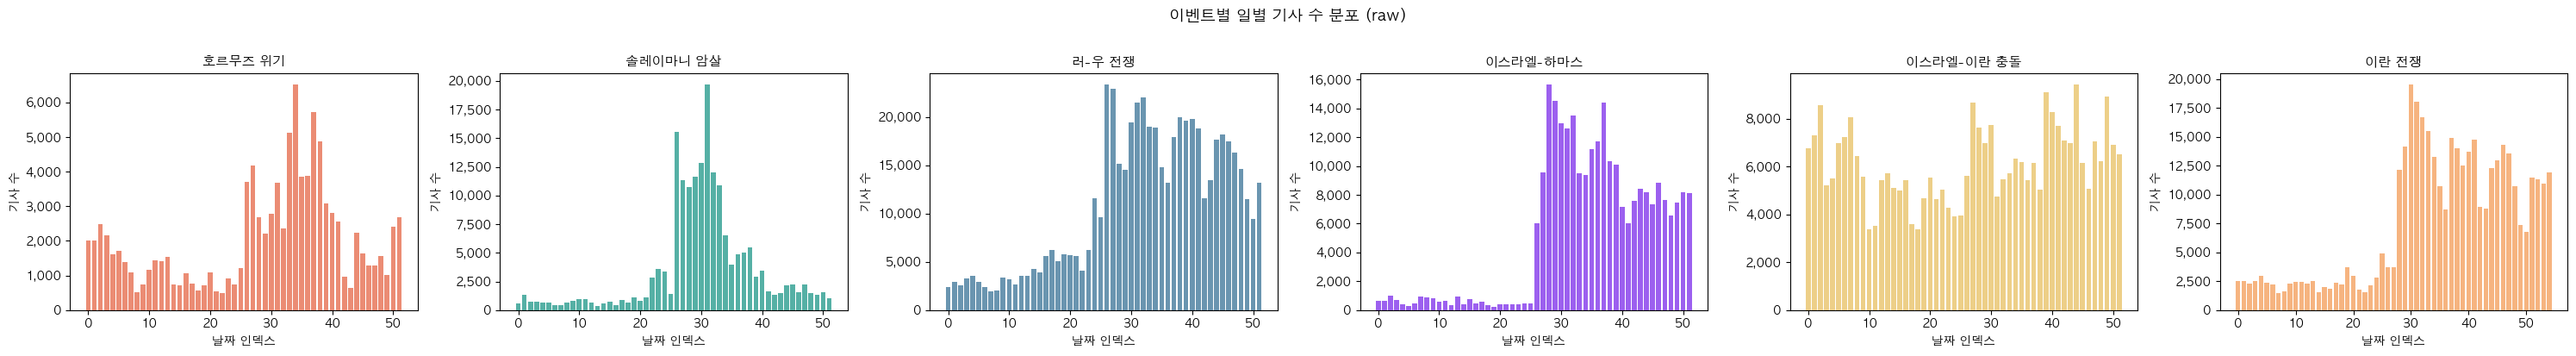

저장: 01_raw_article_count.png


In [11]:
# ── 일별 기사 수 분포 (raw) ───────────────────────────────
if raw_dfs:
    n_raw = len(raw_dfs)
    fig, axes = plt.subplots(1, n_raw, figsize=(5 * n_raw, 4))
    if n_raw == 1:
        axes = [axes]
    for ax, (event, df) in zip(axes, raw_dfs.items()):
        daily_cnt = df.groupby('date').size()
        ax.bar(range(len(daily_cnt)), daily_cnt.values,
               color=COLORS.get(event, 'steelblue'), alpha=0.8)
        ax.set_title(EVENT_LABELS.get(event, event), fontsize=11)
        ax.set_xlabel('날짜 인덱스')
        ax.set_ylabel('기사 수')
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.suptitle('이벤트별 일별 기사 수 분포 (raw)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('01_raw_article_count.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 01_raw_article_count.png')

---
## Step 3. 데이터 전처리

1. **중복 제거** — URL 기준
2. **결측치 처리** — tone 컬럼 NA 제거, 텍스트 컬럼 빈 문자열 대체
3. **이상값 처리** — |tone_score| > 20 제거
4. **지정학 테마 필터** — GEO_THEMES 태그 포함 기사만 유지
5. **`_date` 파생 컬럼** — timezone-naive datetime
6. **최소 기사 수 필터** — 하루 5건 미만 날짜 제거

In [12]:
MIN_DAILY_COUNT    = 5
TONE_OUTLIER_BOUND = 20

def has_geo_theme(themes_str):
    if pd.isna(themes_str) or themes_str == '':
        return False
    return any(tag in themes_str for tag in GEO_THEMES)

def preprocess(df, event_name):
    log = {'event': event_name, 'raw': len(df)}
    df  = df.copy()

    # ① 중복 제거
    df = df.drop_duplicates(subset=['url'])
    log['after_dedup'] = len(df)

    # ② tone 결측 제거
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity'])
    log['after_tone_na'] = len(df)

    # ③ 이상값 제거
    df = df[df['tone_score'].abs() <= TONE_OUTLIER_BOUND]
    log['after_outlier'] = len(df)

    # ④ 텍스트 결측 → 빈 문자열
    for col in ['themes','persons','organizations','locations','source']:
        df[col] = df[col].fillna('')

    # ⑤ _date 파생 컬럼
    # BUG-2 수정: event_timestamp가 이미 tz-aware(UTC)이므로
    #   tz_localize(None) → TypeError. tz_convert(None)으로 변경
    df['_date'] = df['event_timestamp'].dt.tz_convert(None).dt.normalize()

    # ⑥ 지정학 테마 필터
    df = df[df['themes'].apply(has_geo_theme)]
    log['after_geo_filter'] = len(df)

    # ⑦ 최소 기사 수 필터
    daily_cnt   = df.groupby('_date').size()
    valid_dates = daily_cnt[daily_cnt >= MIN_DAILY_COUNT].index
    df = df[df['_date'].isin(valid_dates)]
    log['after_min_count'] = len(df)
    log['valid_days']      = df['_date'].nunique()

    return df, log

clean_dfs = {}
logs = []
print('▶ 데이터 전처리\n')
header = (f'{"이벤트":<30} {"raw":>8} {"중복제거":>8} '
          f'{"이상값":>8} {"지정학":>8} {"최소건수":>8} {"유효일":>6}')
print(header)
print('-' * len(header))
for event, df in raw_dfs.items():
    cleaned, log = preprocess(df, event)
    clean_dfs[event] = cleaned
    logs.append(log)
    print(f"{event:<30} "
          f"{log['raw']:>8,} {log['after_dedup']:>8,} "
          f"{log['after_outlier']:>8,} {log['after_geo_filter']:>8,} "
          f"{log['after_min_count']:>8,} {log['valid_days']:>6}")
preprocess_log_df = pd.DataFrame(logs)
print(f'\n전처리 완료: {len(clean_dfs)}개 이벤트')

▶ 데이터 전처리

이벤트                                 raw     중복제거      이상값      지정학     최소건수    유효일
----------------------------------------------------------------------------------
hormuz_crisis                   106,593  106,593  106,593  106,593  106,593     52
soleimani_assassination         182,733  182,733  182,728  182,728  182,728     52
russia_ukraine_invasion         559,004  559,004  558,933  558,933  558,933     52
israel_hamas                    267,450  267,450  267,411  267,411  267,411     52
israel_iran                     317,163  317,163  317,037  317,037  317,037     52
us_israel_iran                  410,010  410,010  409,969  409,969  409,969     55

전처리 완료: 6개 이벤트


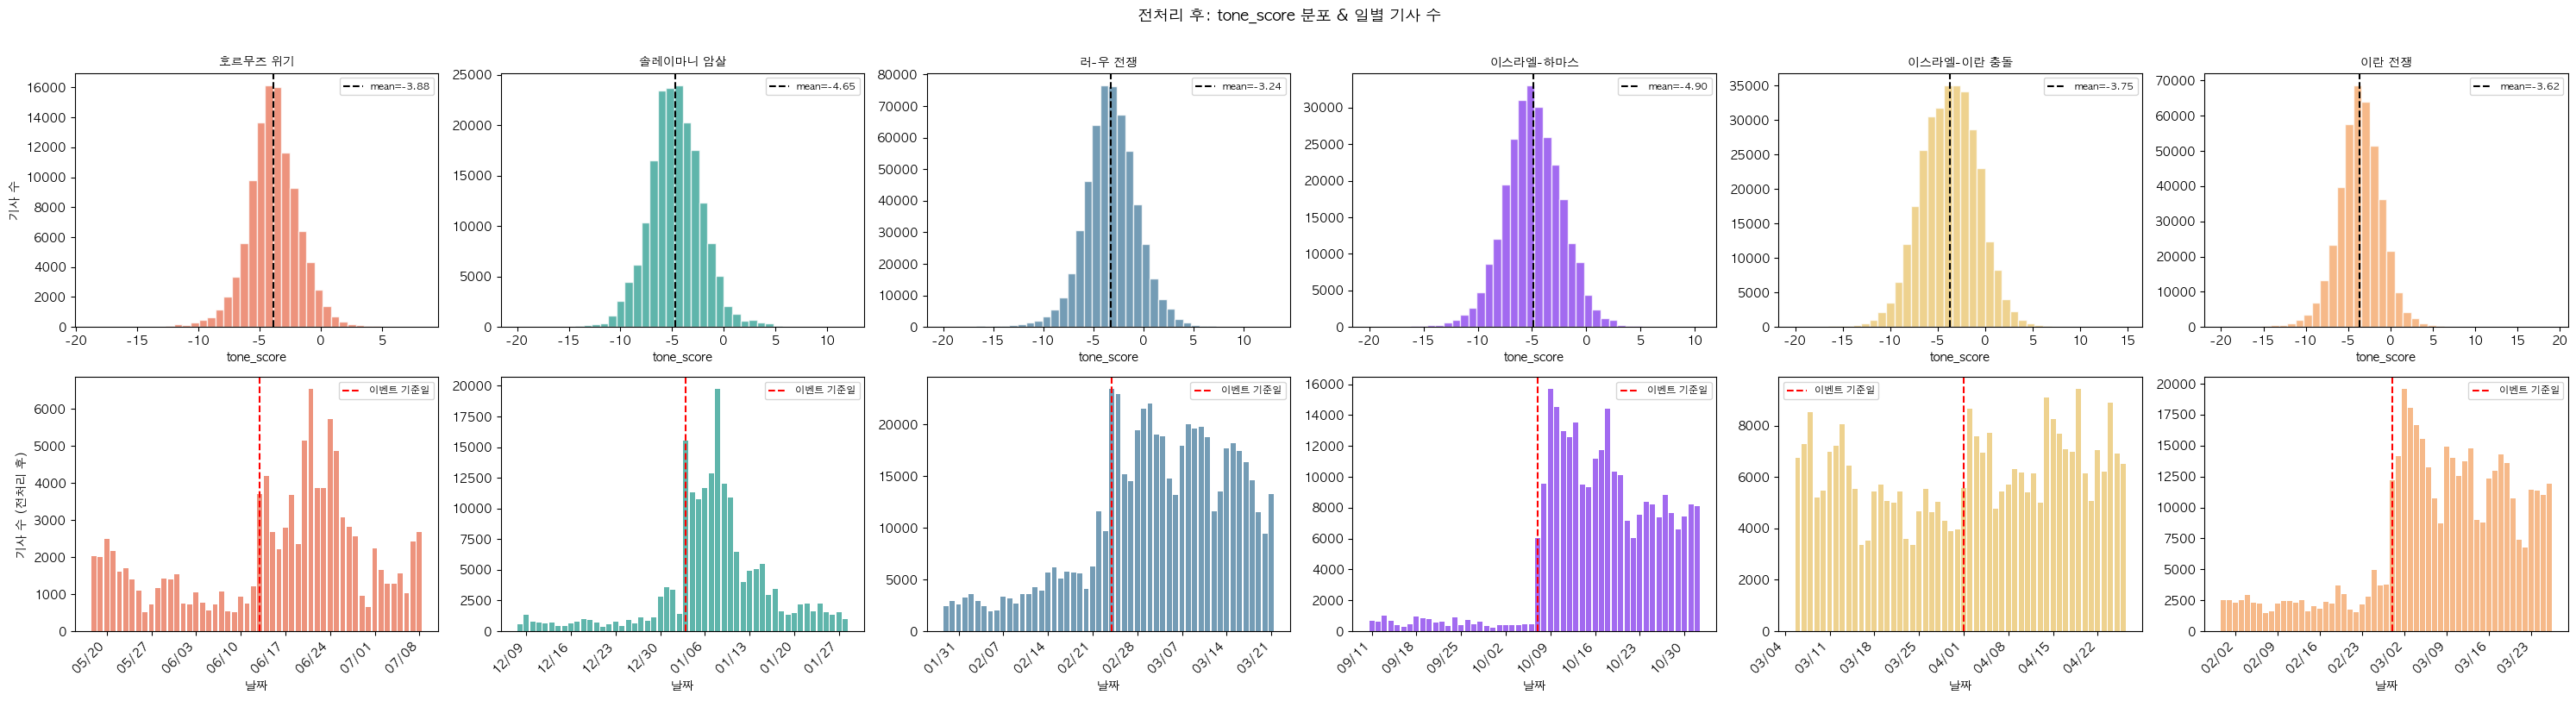

저장: 02_preprocessed_overview.png


In [13]:
# ── 전처리 전후 비교 시각화 ──────────────────────────────
# BUG-3 수정: squeeze=False → 항상 2D axes 배열 반환
#   (이벤트가 1개일 때 axes.reshape(2,1) + axes[0,col_i] 패턴이
#    squeeze=True 기본값 상태에서 1D 배열을 반환해 IndexError 발생)
if clean_dfs:
    n_ev = len(clean_dfs)
    fig, axes = plt.subplots(2, n_ev, figsize=(5 * n_ev, 8), squeeze=False)
    for col_i, (event, df) in enumerate(clean_dfs.items()):
        color = COLORS.get(event, 'steelblue')
        ax0 = axes[0, col_i]
        ax0.hist(df['tone_score'], bins=40, color=color,
                 alpha=0.75, edgecolor='white')
        ax0.axvline(df['tone_score'].mean(), color='black', lw=1.5, ls='--',
                    label=f"mean={df['tone_score'].mean():.2f}")
        ax0.set_title(EVENT_LABELS.get(event, event), fontsize=10)
        ax0.set_xlabel('tone_score')
        ax0.legend(fontsize=8)
        if col_i == 0:
            ax0.set_ylabel('기사 수')

        ax1 = axes[1, col_i]
        daily_cnt = df.groupby('_date').size()
        event_dt  = pd.Timestamp(EVENT_DATES[event])
        ax1.bar(daily_cnt.index, daily_cnt.values, color=color, alpha=0.75)
        ax1.axvline(event_dt, color='red', lw=1.5, ls='--', label='이벤트 기준일')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.set_xlabel('날짜')
        ax1.legend(fontsize=8)
        if col_i == 0:
            ax1.set_ylabel('기사 수 (전처리 후)')

    plt.suptitle('전처리 후: tone_score 분포 & 일별 기사 수', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('02_preprocessed_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 02_preprocessed_overview.png')

---
## Step 4. 공식 GPR 로드

- 원본: 월별 | 변환: 일별 forward fill | 정규화: Z-score
> 다운로드: https://www.matteoiacoviello.com/gpr.htm → `GPR_CURRENT.xlsx`

In [14]:
def load_official_gpr(path):
    if not os.path.exists(path):
        print(f'⚠️  {path} 없음 → 공식 GPR 없이 진행 (F1 기준 내부 상관분석)')
        return None
    try:
        gpr_raw = pd.read_excel(path)
    except Exception:
        try:
            gpr_raw = pd.read_stata(path)
        except Exception as e:
            print(f'GPR 파일 로드 실패: {e}')
            return None

    print('컬럼 목록:', list(gpr_raw.columns))
    print(gpr_raw.head(3))

    date_col = next((c for c in gpr_raw.columns
                     if c.lower() in ['month','date','year','mon']), None)
    gpr_col  = next((c for c in gpr_raw.columns
                     if 'GPR' in c.upper()
                     and 'GPRT' not in c.upper()
                     and 'GPRA' not in c.upper()
                     and 'GPRH' not in c.upper()), None)

    if date_col is None or gpr_col is None:
        print(f'컬럼 탐지 실패 — date_col={date_col}, gpr_col={gpr_col}')
        print("수동 지정: date_col='<날짜컬럼>', gpr_col='<GPR컬럼>'")
        return None

    print(f'\n날짜 컬럼: {date_col}, GPR 컬럼: {gpr_col}')
    gpr_raw[date_col] = pd.to_datetime(gpr_raw[date_col], errors='coerce')
    monthly = (
        gpr_raw[[date_col, gpr_col]].dropna()
        .rename(columns={date_col: 'month', gpr_col: 'GPR'})
        .set_index('month').sort_index()
    )
    daily_idx = pd.date_range(
        monthly.index.min(),
        monthly.index.max() + pd.offsets.MonthEnd(0),
        freq='D')
    daily = monthly.reindex(daily_idx).ffill()
    daily.index.name = 'date'
    daily['GPR_zscore'] = (
        (daily['GPR'] - daily['GPR'].mean()) / daily['GPR'].std())
    print(f'\n공식 GPR: {daily.index.min().date()} ~ {daily.index.max().date()}')
    return daily

gpr_daily = load_official_gpr(GPR_FILE)

컬럼 목록: ['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'N3H', 'GPRH_NOEW', 'GPR_NOEW', 'GPRH_AND', 'GPR_AND', 'GPRH_BASIC', 'GPR_BASIC', 'SHAREH_CAT_1', 'SHAREH_CAT_2', 'SHAREH_CAT_3', 'SHAREH_CAT_4', 'SHAREH_CAT_5', 'SHAREH_CAT_6', 'SHAREH_CAT_7', 'SHAREH_CAT_8', 'GPRC_ARG', 'GPRC_AUS', 'GPRC_BEL', 'GPRC_BRA', 'GPRC_CAN', 'GPRC_CHE', 'GPRC_CHL', 'GPRC_CHN', 'GPRC_COL', 'GPRC_DEU', 'GPRC_DNK', 'GPRC_EGY', 'GPRC_ESP', 'GPRC_FIN', 'GPRC_FRA', 'GPRC_GBR', 'GPRC_HKG', 'GPRC_HUN', 'GPRC_IDN', 'GPRC_IND', 'GPRC_ISR', 'GPRC_ITA', 'GPRC_JPN', 'GPRC_KOR', 'GPRC_MEX', 'GPRC_MYS', 'GPRC_NLD', 'GPRC_NOR', 'GPRC_PER', 'GPRC_PHL', 'GPRC_POL', 'GPRC_PRT', 'GPRC_RUS', 'GPRC_SAU', 'GPRC_SWE', 'GPRC_THA', 'GPRC_TUN', 'GPRC_TUR', 'GPRC_TWN', 'GPRC_UKR', 'GPRC_USA', 'GPRC_VEN', 'GPRC_VNM', 'GPRC_ZAF', 'GPRHC_ARG', 'GPRHC_AUS', 'GPRHC_BEL', 'GPRHC_BRA', 'GPRHC_CAN', 'GPRHC_CHE', 'GPRHC_CHL', 'GPRHC_CHN', 'GPRHC_COL', 'GPRHC_DEU', 'GPRHC_DNK', 'GPRHC_EGY', 'GPRHC

---
## Step 5. GPR 대체 지수 5종 산출

| 공식 | 이름 | 수식 | 참고 문헌 |
|---|---|---|---|
| F1 | 단순 일평균 tone 역전 | `−mean(tone)` | Caldara & Iacoviello 2022 |
| F2 | 극성 가중 tone | `−Σ(tone×polarity)/Σ(polarity)` | BBVA Research 2025 |
| F3 | 보도량×tone 복합 | `−mean(tone) × log(1+N)` | BNP Paribas AM 2022 |
| F4 | 부정 비율 기반 | `neg/(pos+neg)` | Caldara 원본 정신 |
| F5 | 28일 지수가중 이동평균 | F2에 기하 가중 MA 적용 | BBVA Monitor |

In [15]:
def compute_gpr_indices(df, event_name):
    df = df.dropna(subset=['tone_score','positive_score',
                            'negative_score','polarity']).copy()

    # BUG-4 수정 완료
    df['tone_x_polarity'] = df['tone_score'] * df['polarity']

    agg = df.groupby('_date').agg(
        N                   = ('tone_score',      'count'),
        mean_tone           = ('tone_score',      'mean'),
        sum_tone_x_polarity = ('tone_x_polarity', 'sum'),
        sum_polarity        = ('polarity',         'sum'),
        mean_pos            = ('positive_score',  'mean'),
        mean_neg            = ('negative_score',  'mean'),
    ).copy()
    
    # ---------------------------------------------------------
    # [핵심] 보도량 상대적 정규화 (Relative Scaling)
    # ---------------------------------------------------------
    avg_n = agg['N'].mean()
    # 절대적 숫자 N 대신, 해당 이벤트 평균 대비 몇 배나 터졌는지(relative_N)를 사용
    agg['relative_N'] = agg['N'] / avg_n
    agg['coverage_scaled'] = np.log1p(agg['relative_N'])
    
    # F1: 단순 평균 톤 (역전)
    agg['F1_raw'] = -agg['mean_tone']

    # F2: 극성 가중 평균
    agg['F2_raw'] = np.where(
        agg['sum_polarity'] > 0,
        -agg['sum_tone_x_polarity'] / agg['sum_polarity'],
        np.nan)

    # F3: 상대적 보도량 복합 지수 (중복 계산 제거됨)
    agg['F3_raw'] = -agg['mean_tone'] * agg['coverage_scaled']

    # F4: 부정 비율
    denom = agg['mean_pos'] + agg['mean_neg']
    agg['F4_raw'] = np.where(denom > 1e-6, agg['mean_neg'] / denom, np.nan)

    # F5: F2 기반 28일 EWMA
    r, WND = 0.1, 28
    raw_w   = np.array([(1 - r) ** k for k in range(WND)])
    weights = raw_w / raw_w.sum()

    def ewma_28(series):
        result = np.full(len(series), np.nan)
        arr    = series.values
        for i in range(len(arr)):
            window = arr[max(0, i - WND + 1): i + 1][::-1]
            w_cut  = weights[:len(window)]
            w_cut  = w_cut / w_cut.sum()
            valid  = ~np.isnan(window)
            if valid.sum() > 0:
                result[i] = (np.nansum(window[valid] * w_cut[valid])
                             / w_cut[valid].sum())
        return pd.Series(result, index=series.index)

    agg = agg.sort_index()
    agg['F5_raw'] = ewma_28(agg['F2_raw'])

    # Z-score 정규화 (최종 비교용)
    for f in ['F1','F2','F3','F4','F5']:
        col = f'{f}_raw'
        mu, sig = agg[col].mean(), agg[col].std()
        agg[f'{f}_z'] = (agg[col] - mu) / sig if sig > 0 else np.nan

    agg['event_name'] = event_name
    agg['event_date'] = EVENT_DATES[event_name]
    return agg.reset_index().rename(columns={'_date': 'date'})


gpr_results = {}
print('▶ GPR 대체 지수 5종 산출\n')
print(f'{"이벤트":<30} {"유효일":>6} {"F1 mean":>9} {"F2 mean":>9} {"F3 mean":>9}')
print('-' * 70)
for event, df in clean_dfs.items():
    result = compute_gpr_indices(df, event)
    gpr_results[event] = result
    print(f"{event:<30} {len(result):>6} "
          f"{result['F1_raw'].mean():>9.3f} "
          f"{result['F2_raw'].mean():>9.3f} "
          f"{result['F3_raw'].mean():>9.3f}")
gpr_all = pd.concat(gpr_results.values(), ignore_index=True)
print(f'\n산출 완료: 총 {len(gpr_all)}행')

▶ GPR 대체 지수 5종 산출

이벤트                               유효일   F1 mean   F2 mean   F3 mean
----------------------------------------------------------------------
hormuz_crisis                      52     3.686     3.994     2.453
soleimani_assassination            52     4.400     4.901     2.546
russia_ukraine_invasion            52     3.125     3.510     2.057
israel_hamas                       52     4.232     4.704     2.784
israel_iran                        52     3.774     4.282     2.575
us_israel_iran                     55     3.565     4.055     2.256

산출 완료: 총 315행


In [16]:
if gpr_results:
    sample_event = list(gpr_results.keys())[0]
    display_cols = ['date','N','mean_tone',
                    'F1_raw','F2_raw','F3_raw','F4_raw','F5_raw',
                    'F1_z','F2_z','F3_z','F4_z','F5_z']
    print(f'▶ {sample_event} 결과 미리보기')
    display(gpr_results[sample_event][display_cols].head(10).round(3))

▶ hormuz_crisis 결과 미리보기


,date,N,mean_tone,F1_raw,F2_raw,F3_raw,F4_raw,F5_raw,F1_z,F2_z,F3_z,F4_z,F5_z
0,2019-05-18,2022,-5.185,5.185,5.402,3.558,0.816,5.402,2.631,2.452,0.767,2.187,4.107
1,2019-05-19,2004,-4.270,4.270,4.496,2.912,0.771,4.925,1.025,0.874,0.318,0.859,2.596
2,2019-05-20,2480,-4.321,4.321,4.617,3.426,0.791,4.811,1.114,1.086,0.675,1.452,2.236
3,2019-05-21,2163,-3.721,3.721,4.069,2.680,0.762,4.596,0.061,0.131,0.158,0.576,1.553
4,2019-05-22,1613,-4.037,4.037,4.260,2.343,0.777,4.514,0.616,0.463,-0.076,1.028,1.293
5,2019-05-23,1707,-3.744,3.744,3.914,2.268,0.765,4.386,0.102,-0.139,-0.129,0.686,0.887
6,2019-05-24,1385,-3.426,3.426,3.731,1.769,0.743,4.260,-0.457,-0.458,-0.476,0.015,0.490
7,2019-05-25,1091,-3.780,3.780,4.255,1.613,0.741,4.259,0.164,0.455,-0.584,-0.026,0.487
8,2019-05-26,518,-3.420,3.420,3.824,0.770,0.724,4.188,-0.468,-0.296,-1.169,-0.543,0.262
9,2019-05-27,730,-2.928,2.928,3.182,0.892,0.697,4.034,-1.331,-1.413,-1.084,-1.349,-0.227


---
## Step 6. 공식 GPR과 상관관계 분석

- **Pearson r**: 선형 관계 강도
- **Spearman r**: 순위 기반 비선형 관계
- **p-value**: < 0.05 = 통계적 유의
- 공식 GPR 없을 경우 F1~F5 내부 상관분석으로 대체

In [17]:
def merge_with_official_gpr(result_df, gpr_daily_df):
    if gpr_daily_df is None:
        return result_df
    gpr_ref = gpr_daily_df[['GPR','GPR_zscore']].copy()
    gpr_ref.index = pd.to_datetime(gpr_ref.index)
    result_df = result_df.copy()
    result_df['date'] = pd.to_datetime(result_df['date'])
    result_df = result_df.set_index('date').join(gpr_ref, how='left')
    return result_df.reset_index()


def correlation_analysis(result_df, event_name, gpr_available):
    # BUG-5 수정: ref_series 변수 선언 후 미사용 → 제거하고 로직 단순화
    rows           = []
    formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']

    if gpr_available and 'GPR_zscore' in result_df.columns:
        ref_label    = 'GPR 공식 (Z-score)'
        target_col   = 'GPR_zscore'
        compare_cols = formula_cols_z
    else:
        ref_label    = 'F1_z (기준)'
        target_col   = 'F1_z'
        compare_cols = formula_cols_z[1:]  # F2~F5 vs F1

    for f_col in compare_cols:
        pair = result_df[[f_col, target_col]].dropna()
        if len(pair) < 5:
            rows.append({'formula': f_col, 'n': len(pair),
                         'pearson_r': np.nan, 'pearson_p': np.nan,
                         'spearman_r': np.nan, 'spearman_p': np.nan})
            continue
        pr, pp = stats.pearsonr(pair[f_col], pair[target_col])
        sr, sp = stats.spearmanr(pair[f_col], pair[target_col])
        rows.append({'formula': f_col, 'n': len(pair),
                     'pearson_r': pr, 'pearson_p': pp,
                     'spearman_r': sr, 'spearman_p': sp})

    corr_df = pd.DataFrame(rows)
    corr_df['event']    = event_name
    corr_df['ref']      = ref_label
    corr_df['sig_5pct'] = corr_df['pearson_p'].apply(
        lambda p: '✅' if (pd.notna(p) and p < 0.05) else '—')
    return corr_df


gpr_available  = gpr_daily is not None
merged_results = {}
for event, result in gpr_results.items():
    merged_results[event] = merge_with_official_gpr(result, gpr_daily)

all_corr = []
print(f'▶ 상관관계 분석 ({"공식 GPR 기준" if gpr_available else "F1 기준"})\n')
for event, result in merged_results.items():
    corr_df = correlation_analysis(result, event, gpr_available)
    all_corr.append(corr_df)
    print(f'  [{EVENT_LABELS.get(event, event)}]')
    print(corr_df[['formula','n','pearson_r','pearson_p',
                    'spearman_r','spearman_p','sig_5pct']].to_string(index=False))
    print()

# BUG-6 수정: all_corr가 비어있으면 pd.concat → ValueError
#   → 빈 경우 빈 DataFrame으로 안전 처리
corr_summary = pd.concat(all_corr, ignore_index=True) if all_corr else pd.DataFrame()

▶ 상관관계 분석 (공식 GPR 기준)

  [호르무즈 위기]
formula  n  pearson_r  pearson_p  spearman_r  spearman_p sig_5pct
   F1_z 52   0.257702   0.065120    0.117647    0.406180        —
   F2_z 52   0.274104   0.049254    0.154743    0.273360        ✅
   F3_z 52   0.129997   0.358338    0.093270    0.510753        —
   F4_z 52   0.260230   0.062438    0.056174    0.692443        —
   F5_z 52   0.275285   0.048245   -0.086911    0.540109        ✅

  [솔레이마니 암살]
formula  n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 52   0.192597 1.713358e-01    0.192772 1.709402e-01        —
   F2_z 52   0.121997 3.889248e-01    0.141366 3.174764e-01        —
   F3_z 52   0.594592 3.353125e-06    0.763378 4.696550e-11        ✅
   F4_z 52   0.373027 6.457072e-03    0.388115 4.468045e-03        ✅
   F5_z 52   0.638530 3.522616e-07    0.627152 6.528848e-07        ✅

  [러-우 전쟁]
formula  n  pearson_r    pearson_p  spearman_r   spearman_p sig_5pct
   F1_z 52   0.103047 4.672512e-01    0.148131 2.946323e-01 

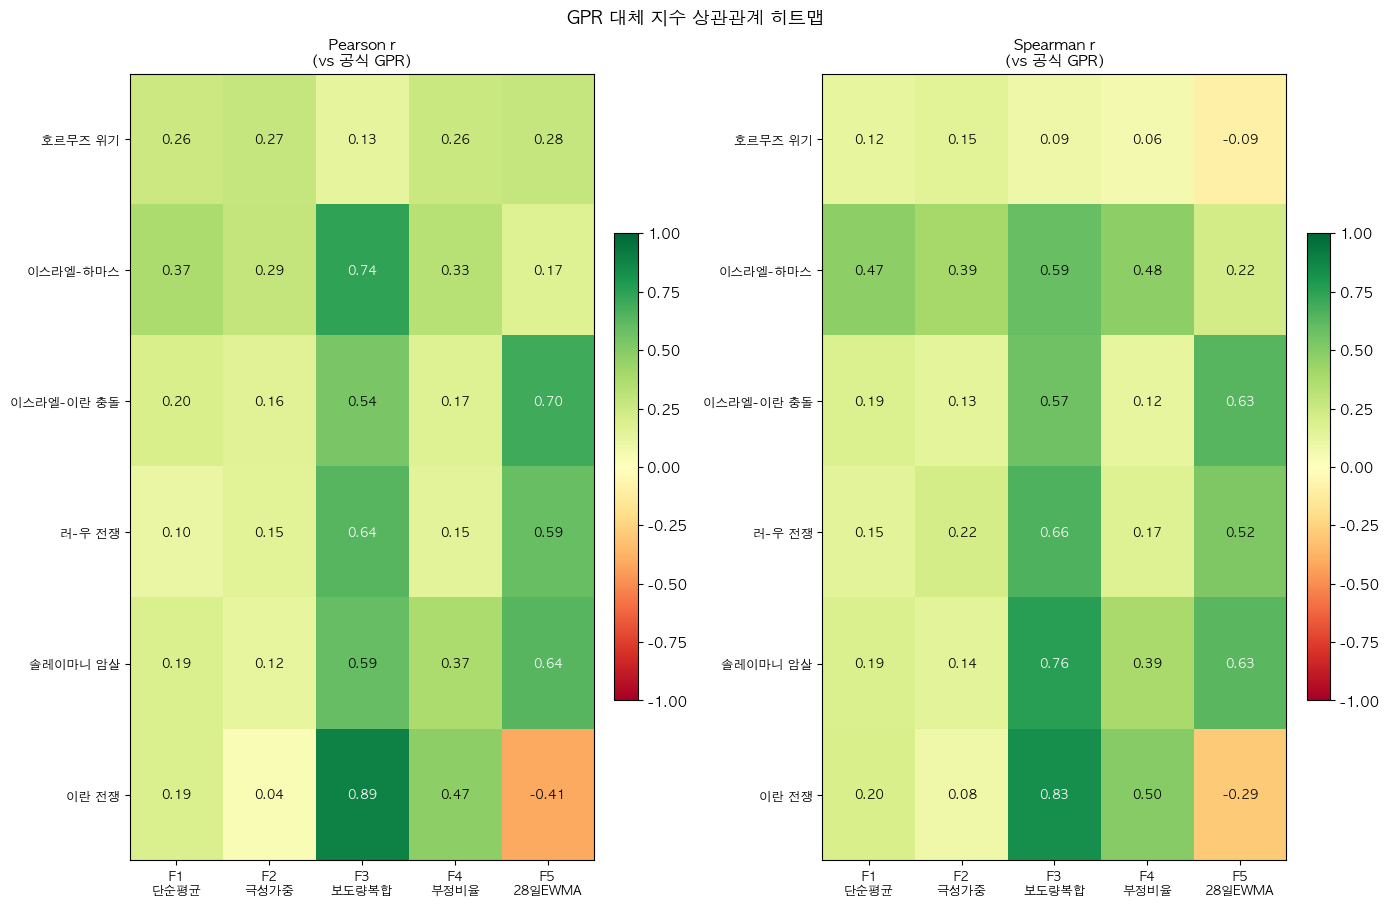

저장: 03_correlation_heatmap.png


In [18]:
# ── 상관계수 히트맵 ───────────────────────────────────────
formula_cols_z = ['F1_z','F2_z','F3_z','F4_z','F5_z']
formula_labels = ['F1\n단순평균','F2\n극성가중','F3\n보도량복합',
                  'F4\n부정비율','F5\n28일EWMA']

if corr_summary.empty:
    print('상관관계 데이터 없음 — 히트맵 생략')
else:
    fig, axes = plt.subplots(1, 2,
                             figsize=(14, max(4, len(gpr_results) * 1.2 + 2)))
    for ax_i, (metric, metric_label) in enumerate(
            [('pearson_r','Pearson r'), ('spearman_r','Spearman r')]):
        ax = axes[ax_i]
        pivot = corr_summary.pivot_table(
            index='event', columns='formula', values=metric, aggfunc='first')
        pivot = pivot.reindex(
            columns=[c for c in formula_cols_z if c in pivot.columns])
        im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn',
                       vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(
            [formula_labels[formula_cols_z.index(c)]
             for c in pivot.columns], fontsize=9)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(
            [EVENT_LABELS.get(e, e) for e in pivot.index], fontsize=9)
        ax.set_title(
            f'{metric_label}\n({"vs 공식 GPR" if gpr_available else "vs F1"})',
            fontsize=11)
        for row in range(pivot.shape[0]):
            for col in range(pivot.shape[1]):
                val = pivot.values[row, col]
                if pd.notna(val):
                    ax.text(col, row, f'{val:.2f}', ha='center', va='center',
                            fontsize=9,
                            color='white' if abs(val) > 0.6 else 'black')
    plt.suptitle('GPR 대체 지수 상관관계 히트맵', fontsize=13)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 03_correlation_heatmap.png')

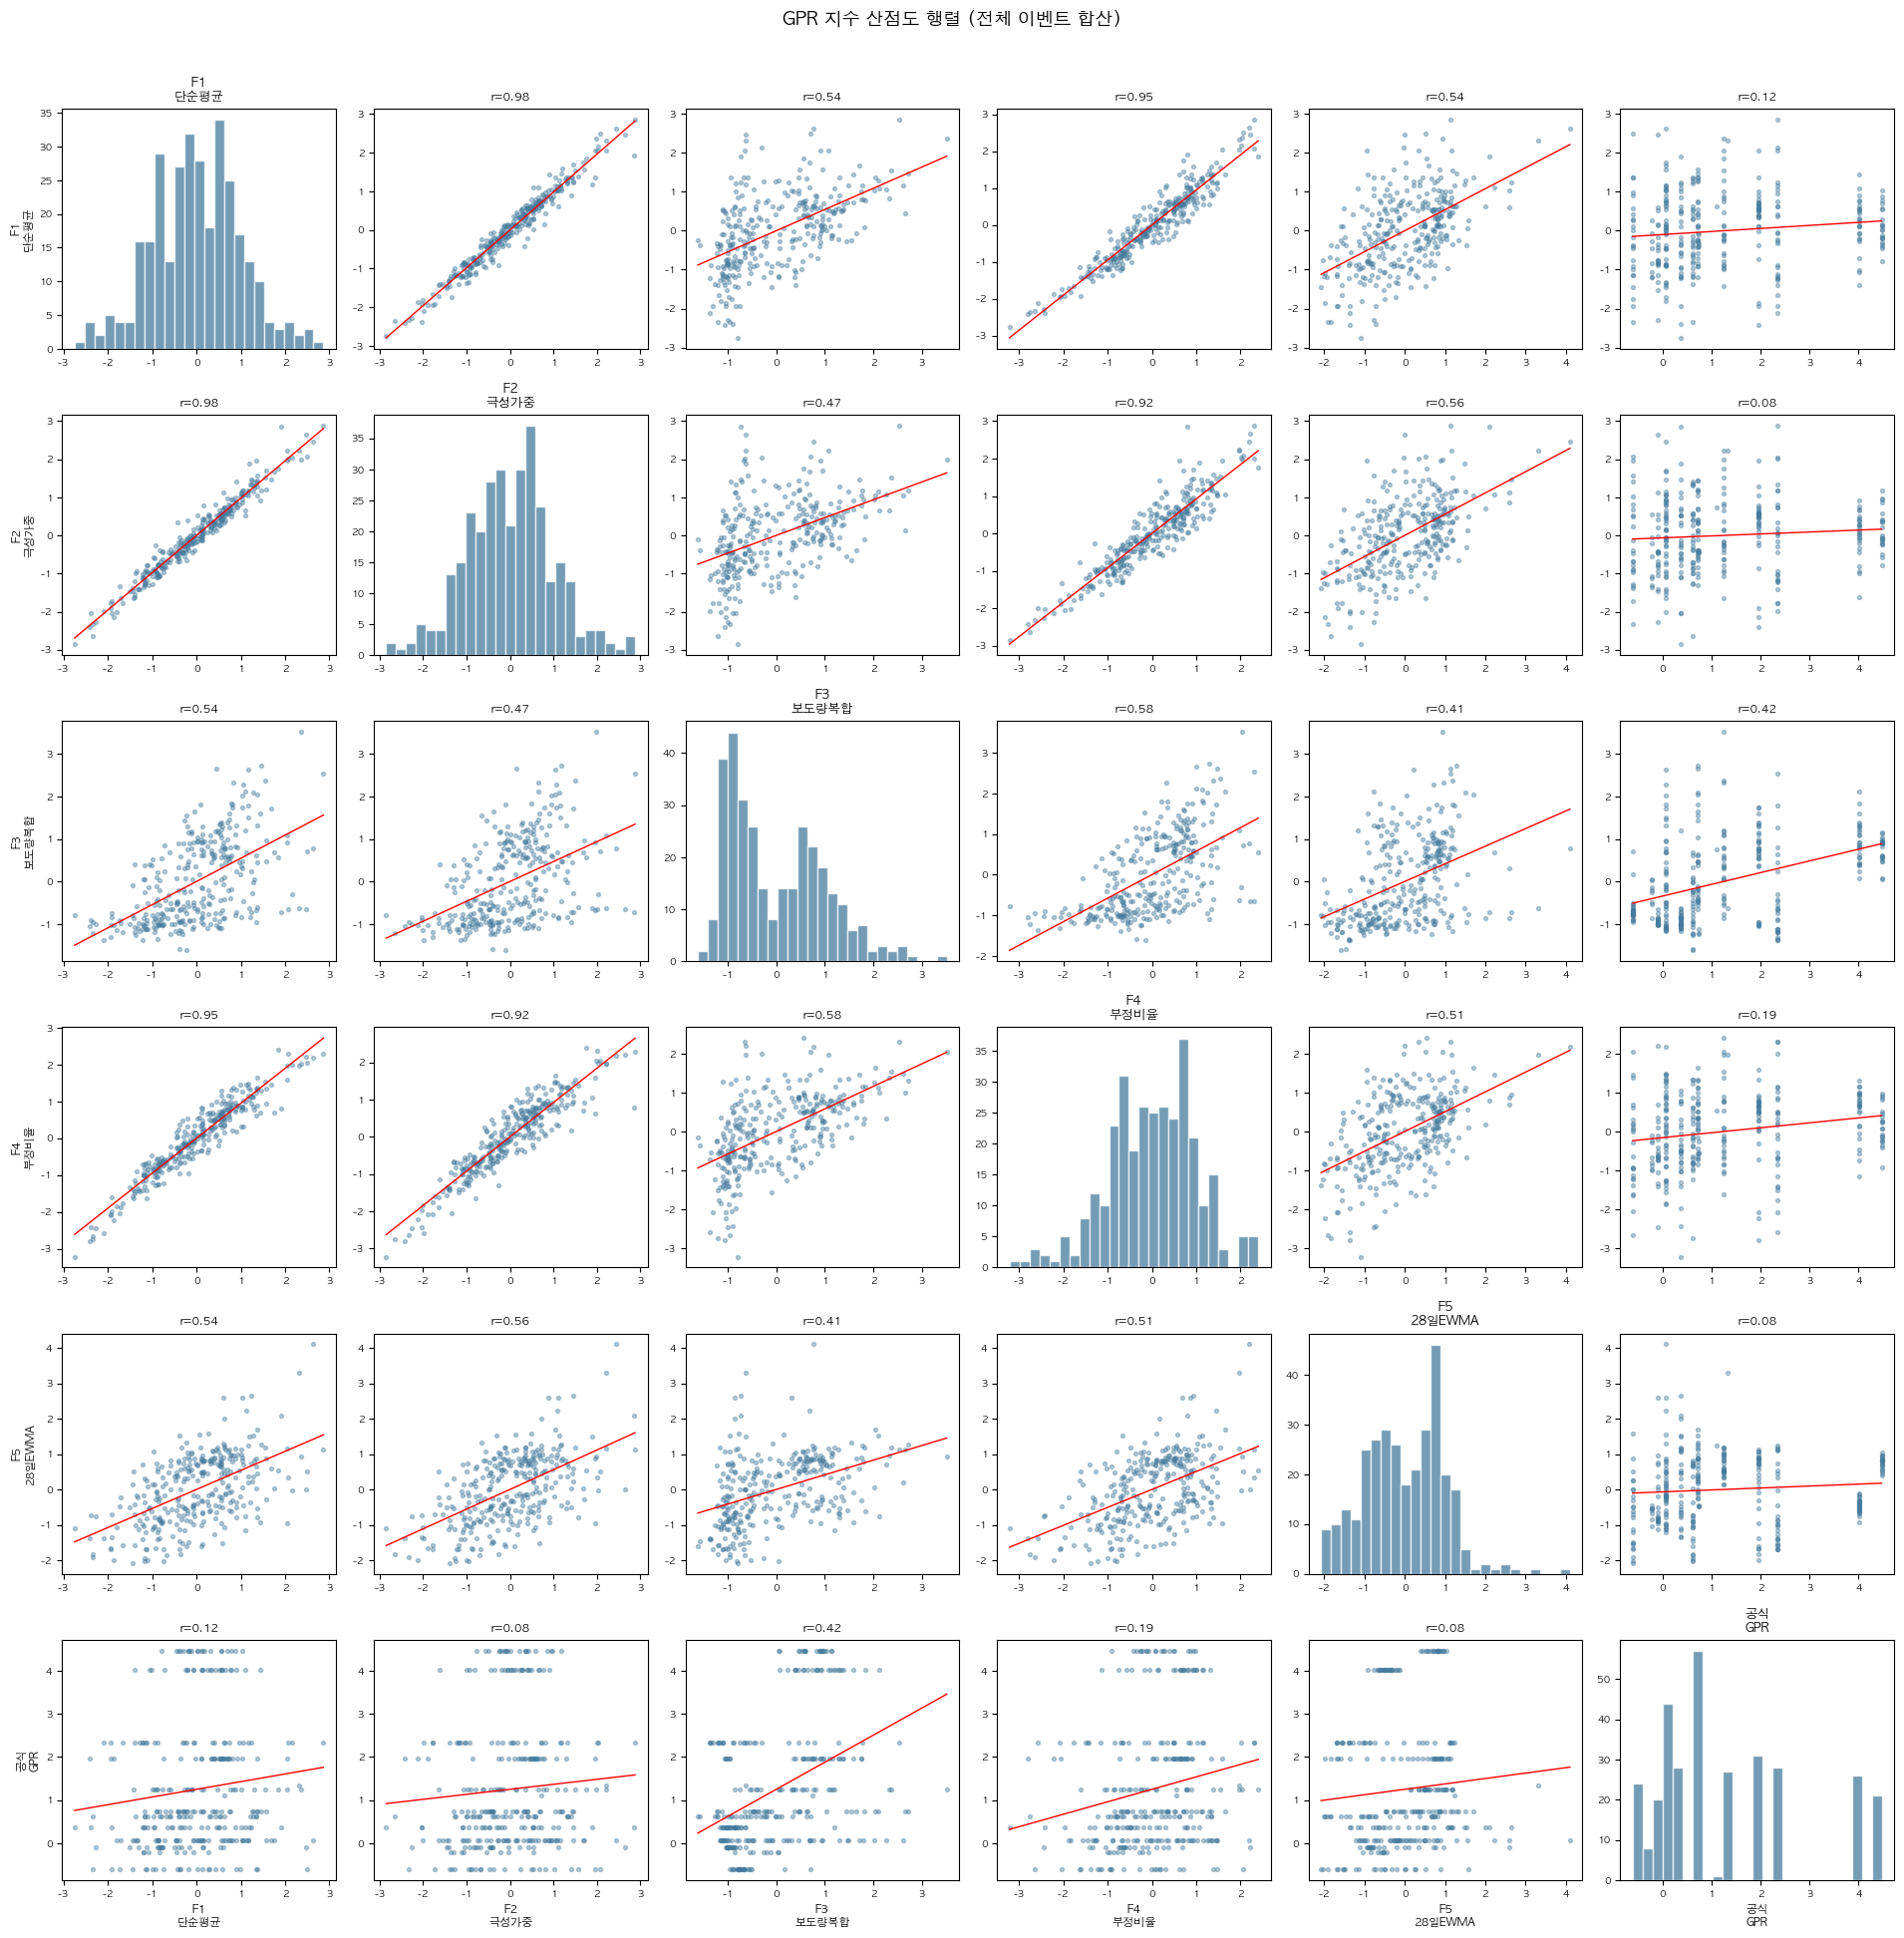

저장: 04_scatter_matrix.png


In [19]:
# ── F1~F5 산점도 행렬 ────────────────────────────────────
z_cols     = ['F1_z','F2_z','F3_z','F4_z','F5_z']
all_merged = pd.concat(merged_results.values(), ignore_index=True)

if gpr_available and 'GPR_zscore' in all_merged.columns:
    scatter_cols   = z_cols + ['GPR_zscore']
    scatter_labels = formula_labels + ['공식\nGPR']
else:
    scatter_cols   = z_cols
    scatter_labels = formula_labels

n_sc = len(scatter_cols)
fig, axes = plt.subplots(n_sc, n_sc, figsize=(3.2 * n_sc, 3.2 * n_sc))
for i, (ci, li) in enumerate(zip(scatter_cols, scatter_labels)):
    for j, (cj, lj) in enumerate(zip(scatter_cols, scatter_labels)):
        ax = axes[i, j]
        if i == j:
            data = all_merged[ci].dropna()
            ax.hist(data, bins=25, color='#457B9D', alpha=0.75, edgecolor='white')
            ax.set_title(li, fontsize=9)
        else:
            xy = all_merged[[ci, cj]].dropna()
            if len(xy) > 2:
                ax.scatter(xy[cj], xy[ci], s=8, alpha=0.4, color='#457B9D')
                m, b = np.polyfit(xy[cj], xy[ci], 1)
                xr = np.linspace(xy[cj].min(), xy[cj].max(), 50)
                ax.plot(xr, m * xr + b, 'r-', lw=1)
                r, _ = stats.pearsonr(xy[ci], xy[cj])
                ax.set_title(f'r={r:.2f}', fontsize=8)
        if i == n_sc - 1: ax.set_xlabel(lj, fontsize=8)
        if j == 0:        ax.set_ylabel(li, fontsize=8)
        ax.tick_params(labelsize=7)
plt.suptitle('GPR 지수 산점도 행렬 (전체 이벤트 합산)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('04_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_scatter_matrix.png')

---
## Step 7. 시각화

### 7-1. 이벤트별 F1~F5 시계열

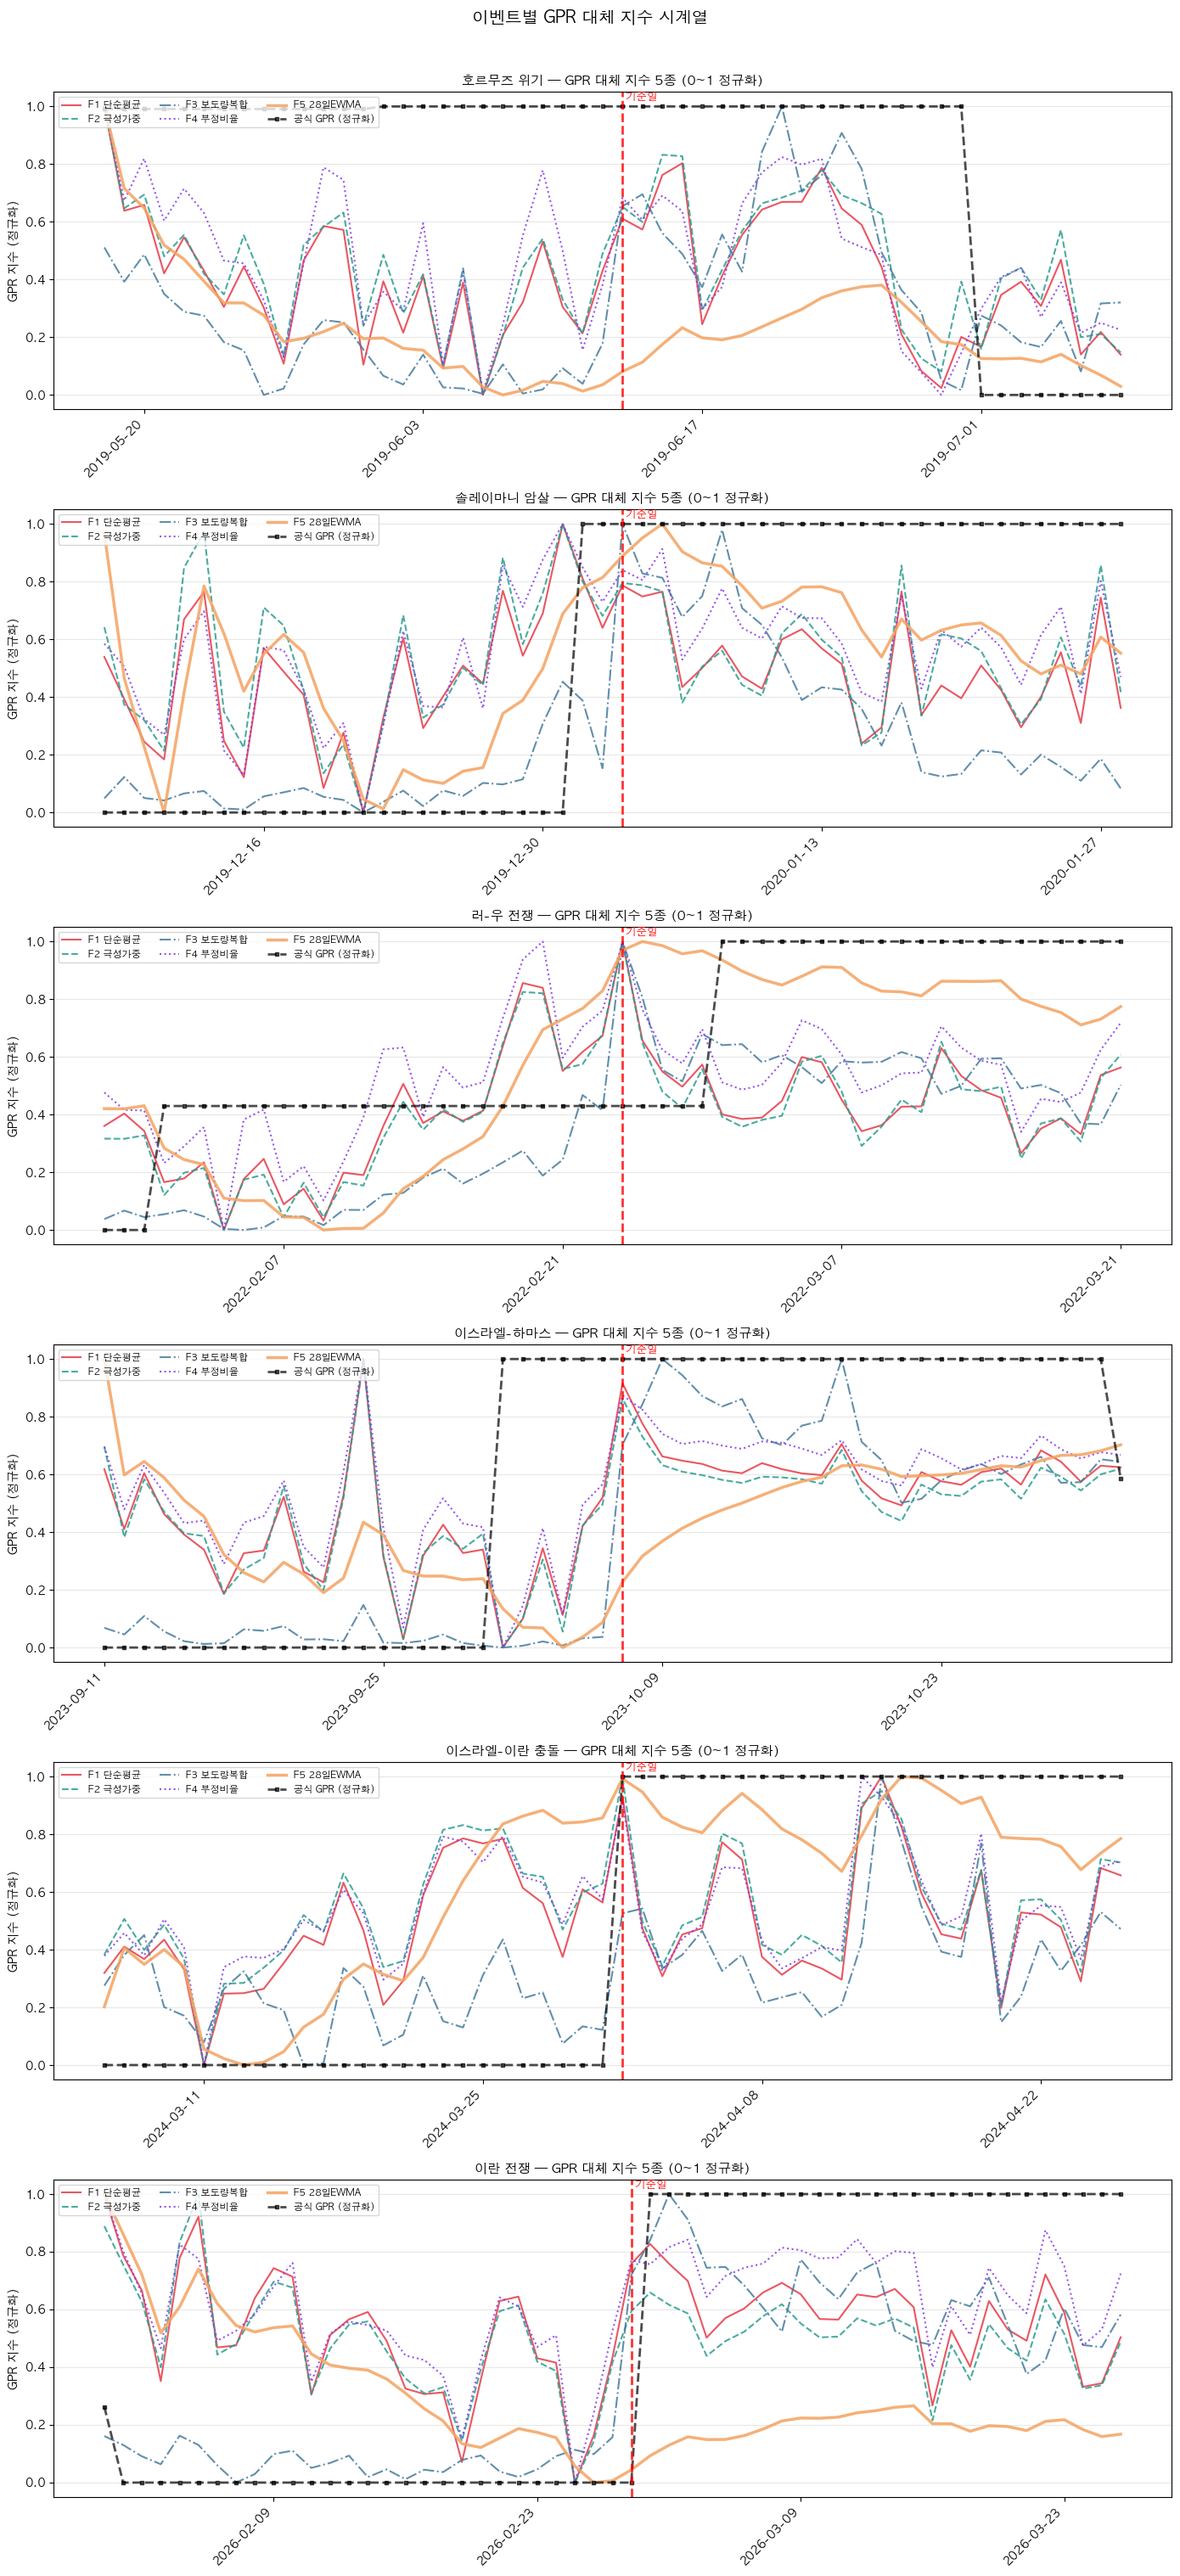

저장: 05_gpr_timeseries.png


In [20]:
raw_cols   = ['F1_raw','F2_raw','F3_raw','F4_raw','F5_raw']
raw_styles = [('-','#E63946'),('--','#2A9D8F'),('-.','#457B9D'),
              (':','#8338EC'),('-','#F4A261')]
raw_widths = [1.5, 1.5, 1.5, 1.5, 2.5]
raw_labels = ['F1 단순평균','F2 극성가중','F3 보도량복합',
              'F4 부정비율','F5 28일EWMA']

n_events = len(merged_results)
fig, axes = plt.subplots(n_events, 1, figsize=(14, 5 * n_events), sharex=False)
if n_events == 1:
    axes = [axes]

for ax, (event, result) in zip(axes, merged_results.items()):
    result   = result.copy()
    result['date'] = pd.to_datetime(result['date'])
    result   = result.sort_values('date')
    event_dt = pd.Timestamp(EVENT_DATES[event])

    for col in raw_cols:
        mn, mx = result[col].min(), result[col].max()
        result[col + '_norm'] = (
            (result[col] - mn) / (mx - mn) if mx > mn else 0.5)

    for (ls, clr), lw, lbl, col in zip(raw_styles, raw_widths, raw_labels, raw_cols):
        ax.plot(result['date'], result[col + '_norm'],
                ls=ls, color=clr, lw=lw, label=lbl, alpha=0.85)

    if gpr_available and 'GPR_zscore' in result.columns:
        gpr_sub = result[['date','GPR_zscore']].dropna()
        if len(gpr_sub) > 0:
            mn, mx  = gpr_sub['GPR_zscore'].min(), gpr_sub['GPR_zscore'].max()
            gpr_norm = (
                (gpr_sub['GPR_zscore'] - mn) / (mx - mn) if mx > mn else 0.5)
            ax.plot(gpr_sub['date'], gpr_norm, 's--', color='black',
                    lw=2, ms=3, label='공식 GPR (정규화)', alpha=0.7)

    ax.axvline(event_dt, color='red', lw=2, ls='--', alpha=0.8)
    # BUG-7 수정: axvline 직후 ax.get_ylim()[1] 호출 시 아직 ylim=(0,1) 기본값
    #   → get_xaxis_transform()으로 axes 좌표계 기준 상단 고정
    ax.text(event_dt, 1.0, ' 기준일', color='red', fontsize=9,
            va='top', transform=ax.get_xaxis_transform())

    ax.set_title(
        f'{EVENT_LABELS.get(event, event)} — GPR 대체 지수 5종 (0~1 정규화)',
        fontsize=11)
    ax.set_ylabel('GPR 지수 (정규화)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(fontsize=8, loc='upper left', ncol=3)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('이벤트별 GPR 대체 지수 시계열', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('05_gpr_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 05_gpr_timeseries.png')

### 7-2. 공식 GPR vs 우리 지수 직접 비교 (공식 GPR 있을 때)

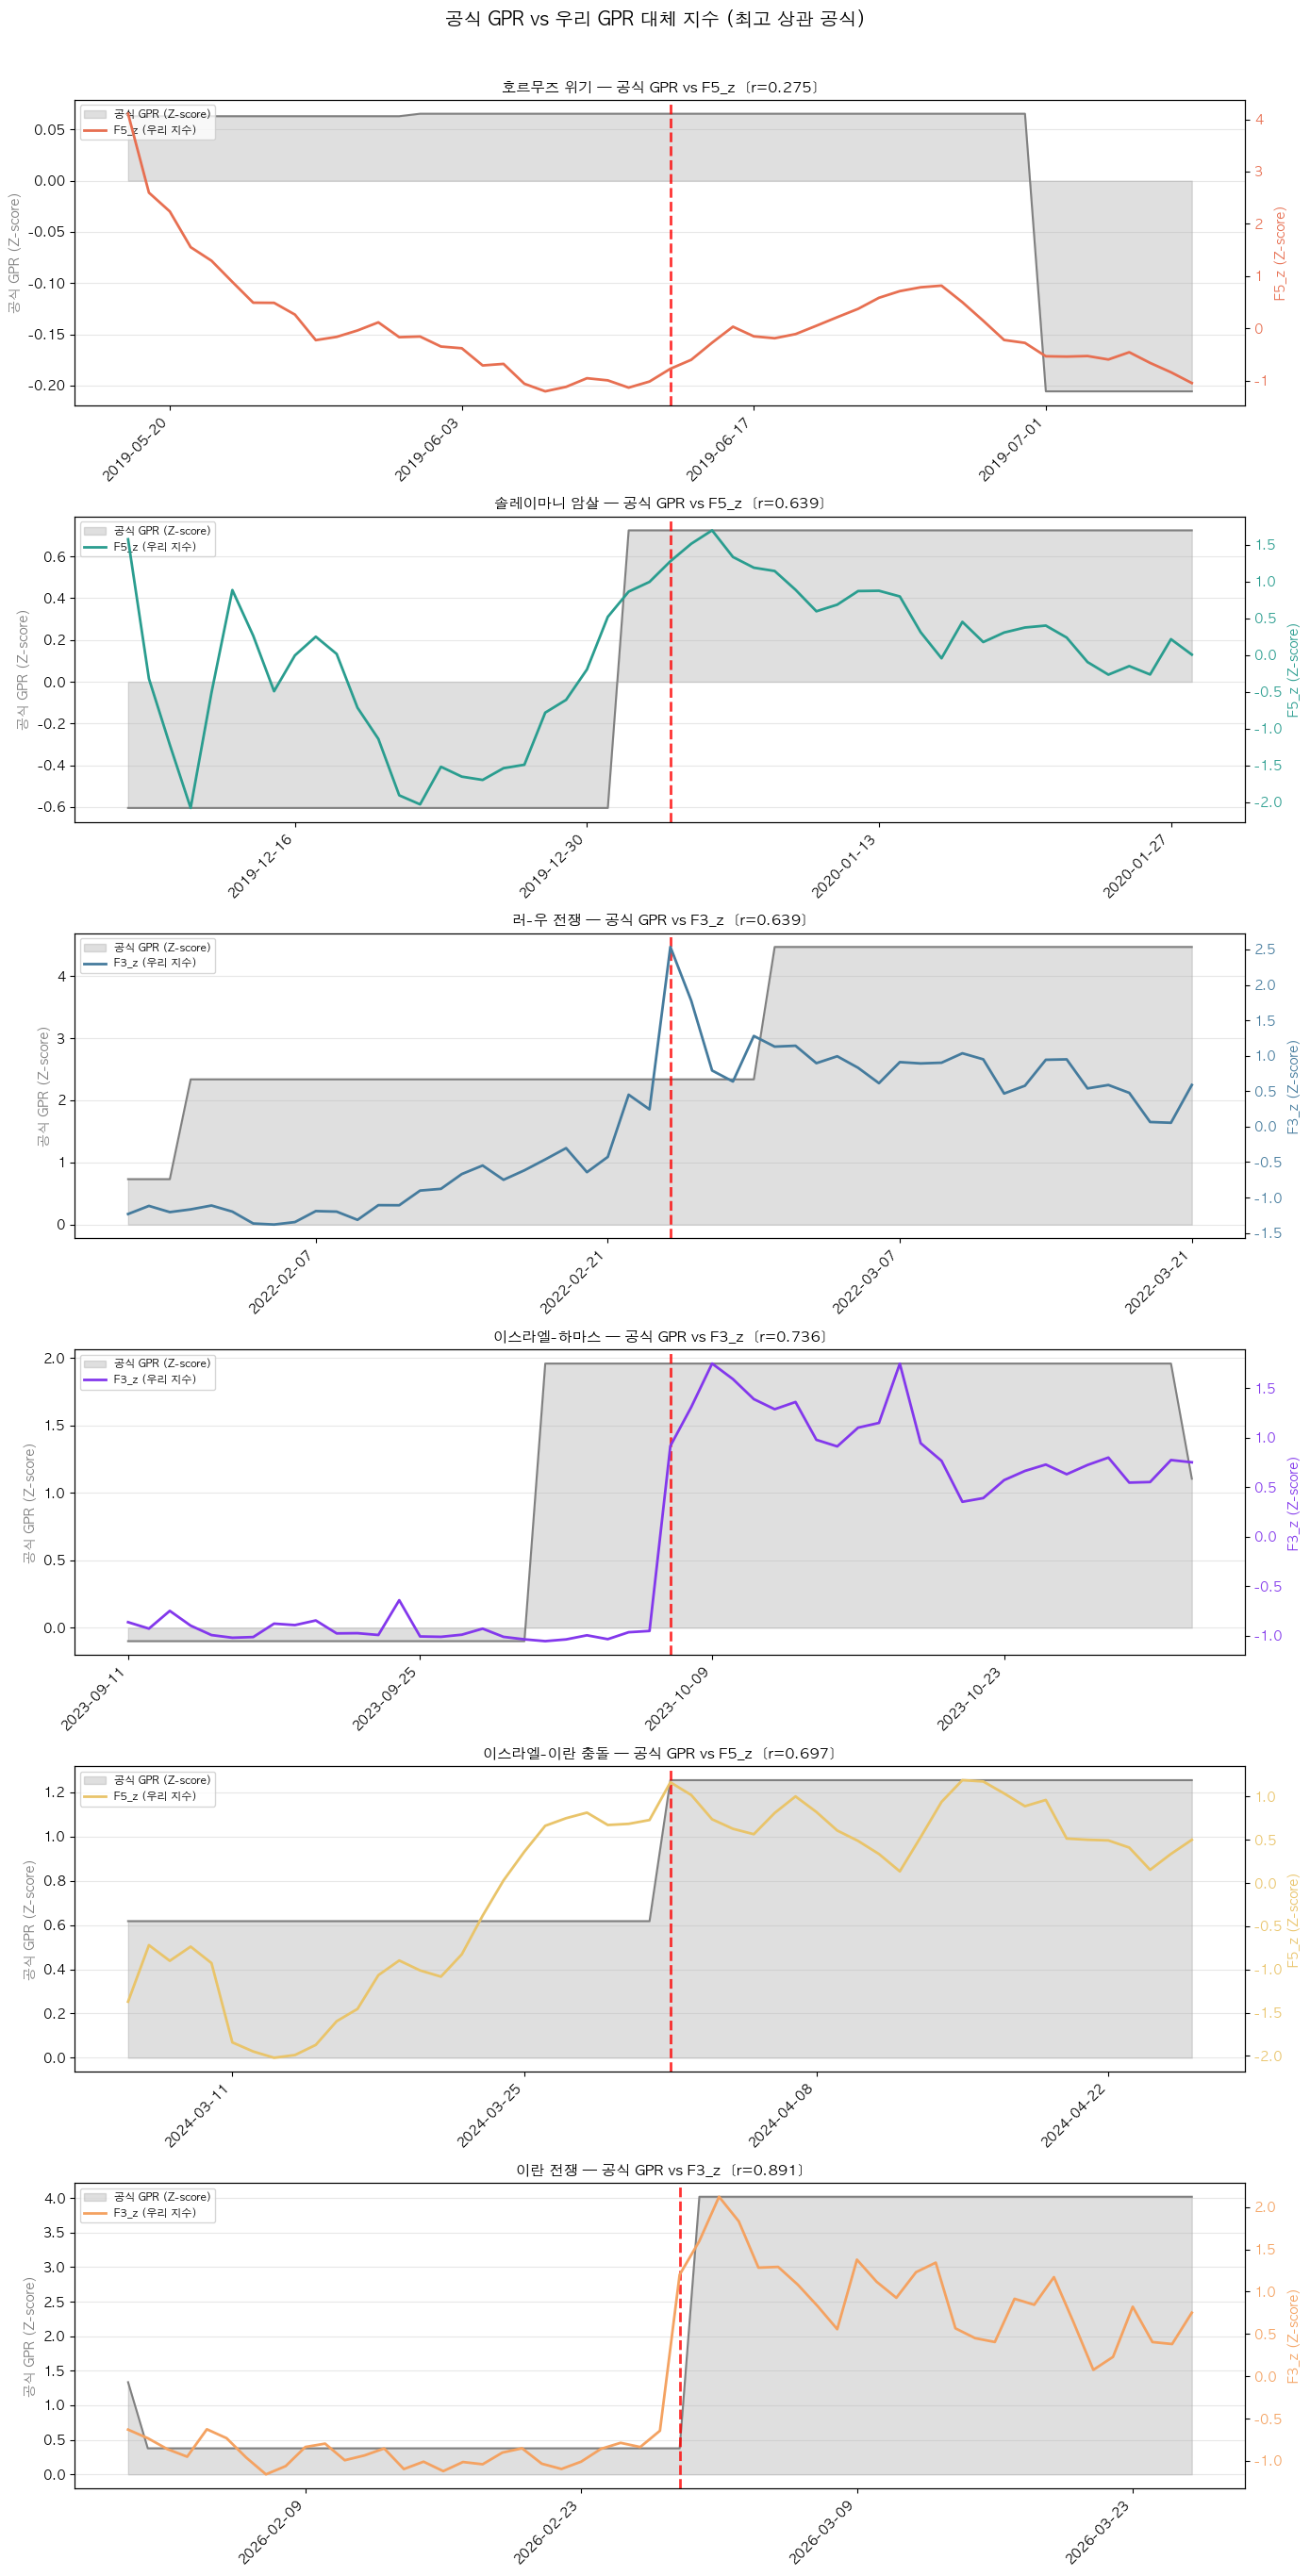

저장: 06_official_vs_ours.png


In [21]:
# BUG-8 수정: 원본 코드에서 if 블록 내 plt.show() 직후에 else:가
#   같은 셀 소스 문자열 안에서 이어졌으나 개행 처리 오류로 분리됨
#   → IndentationError. 정상적인 if/else 블록으로 재작성
if gpr_available:
    n_events = len(merged_results)
    fig, axes = plt.subplots(n_events, 1, figsize=(14, 4.5 * n_events))
    if n_events == 1:
        axes = [axes]

    best_formula = (
        corr_summary
        .loc[corr_summary.groupby('event')['pearson_r'].idxmax()]
        .set_index('event')['formula']
        if not corr_summary.empty else pd.Series(dtype=str)
    )

    for ax, (event, result) in zip(axes, merged_results.items()):
        result   = result.copy()
        result['date'] = pd.to_datetime(result['date'])
        result   = result.sort_values('date')
        event_dt = pd.Timestamp(EVENT_DATES[event])
        color    = COLORS.get(event, 'steelblue')
        best     = best_formula.get(event, 'F2_z')

        ax2 = ax.twinx()
        gpr_sub = result[['date','GPR_zscore']].dropna()
        ax.fill_between(gpr_sub['date'], gpr_sub['GPR_zscore'],
                        alpha=0.25, color='gray', label='공식 GPR (Z-score)')
        ax.plot(gpr_sub['date'], gpr_sub['GPR_zscore'], color='gray', lw=1.5)
        ax.set_ylabel('공식 GPR (Z-score)', color='gray')

        our_sub = result[['date', best]].dropna()
        ax2.plot(our_sub['date'], our_sub[best],
                 color=color, lw=2, label=f'{best} (우리 지수)')
        ax2.set_ylabel(f'{best} (Z-score)', color=color)
        ax2.tick_params(axis='y', labelcolor=color)

        r_row = corr_summary.loc[
            (corr_summary['event'] == event) &
            (corr_summary['formula'] == best), 'pearson_r']
        r_str = f'r={r_row.values[0]:.3f}' if len(r_row) > 0 else ''
        ax.set_title(
            f'{EVENT_LABELS.get(event, event)} — 공식 GPR vs {best}  [{r_str}]',
            fontsize=11)

        ax.axvline(event_dt, color='red', lw=2, ls='--', alpha=0.8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle('공식 GPR vs 우리 GPR 대체 지수 (최고 상관 공식)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('06_official_vs_ours.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 06_official_vs_ours.png')
else:
    print('공식 GPR 파일 없음 → 이 셀은 건너뜁니다.')

### 7-3. 이벤트 전후 ±26일 GPR 변화 (이벤트 스터디형)

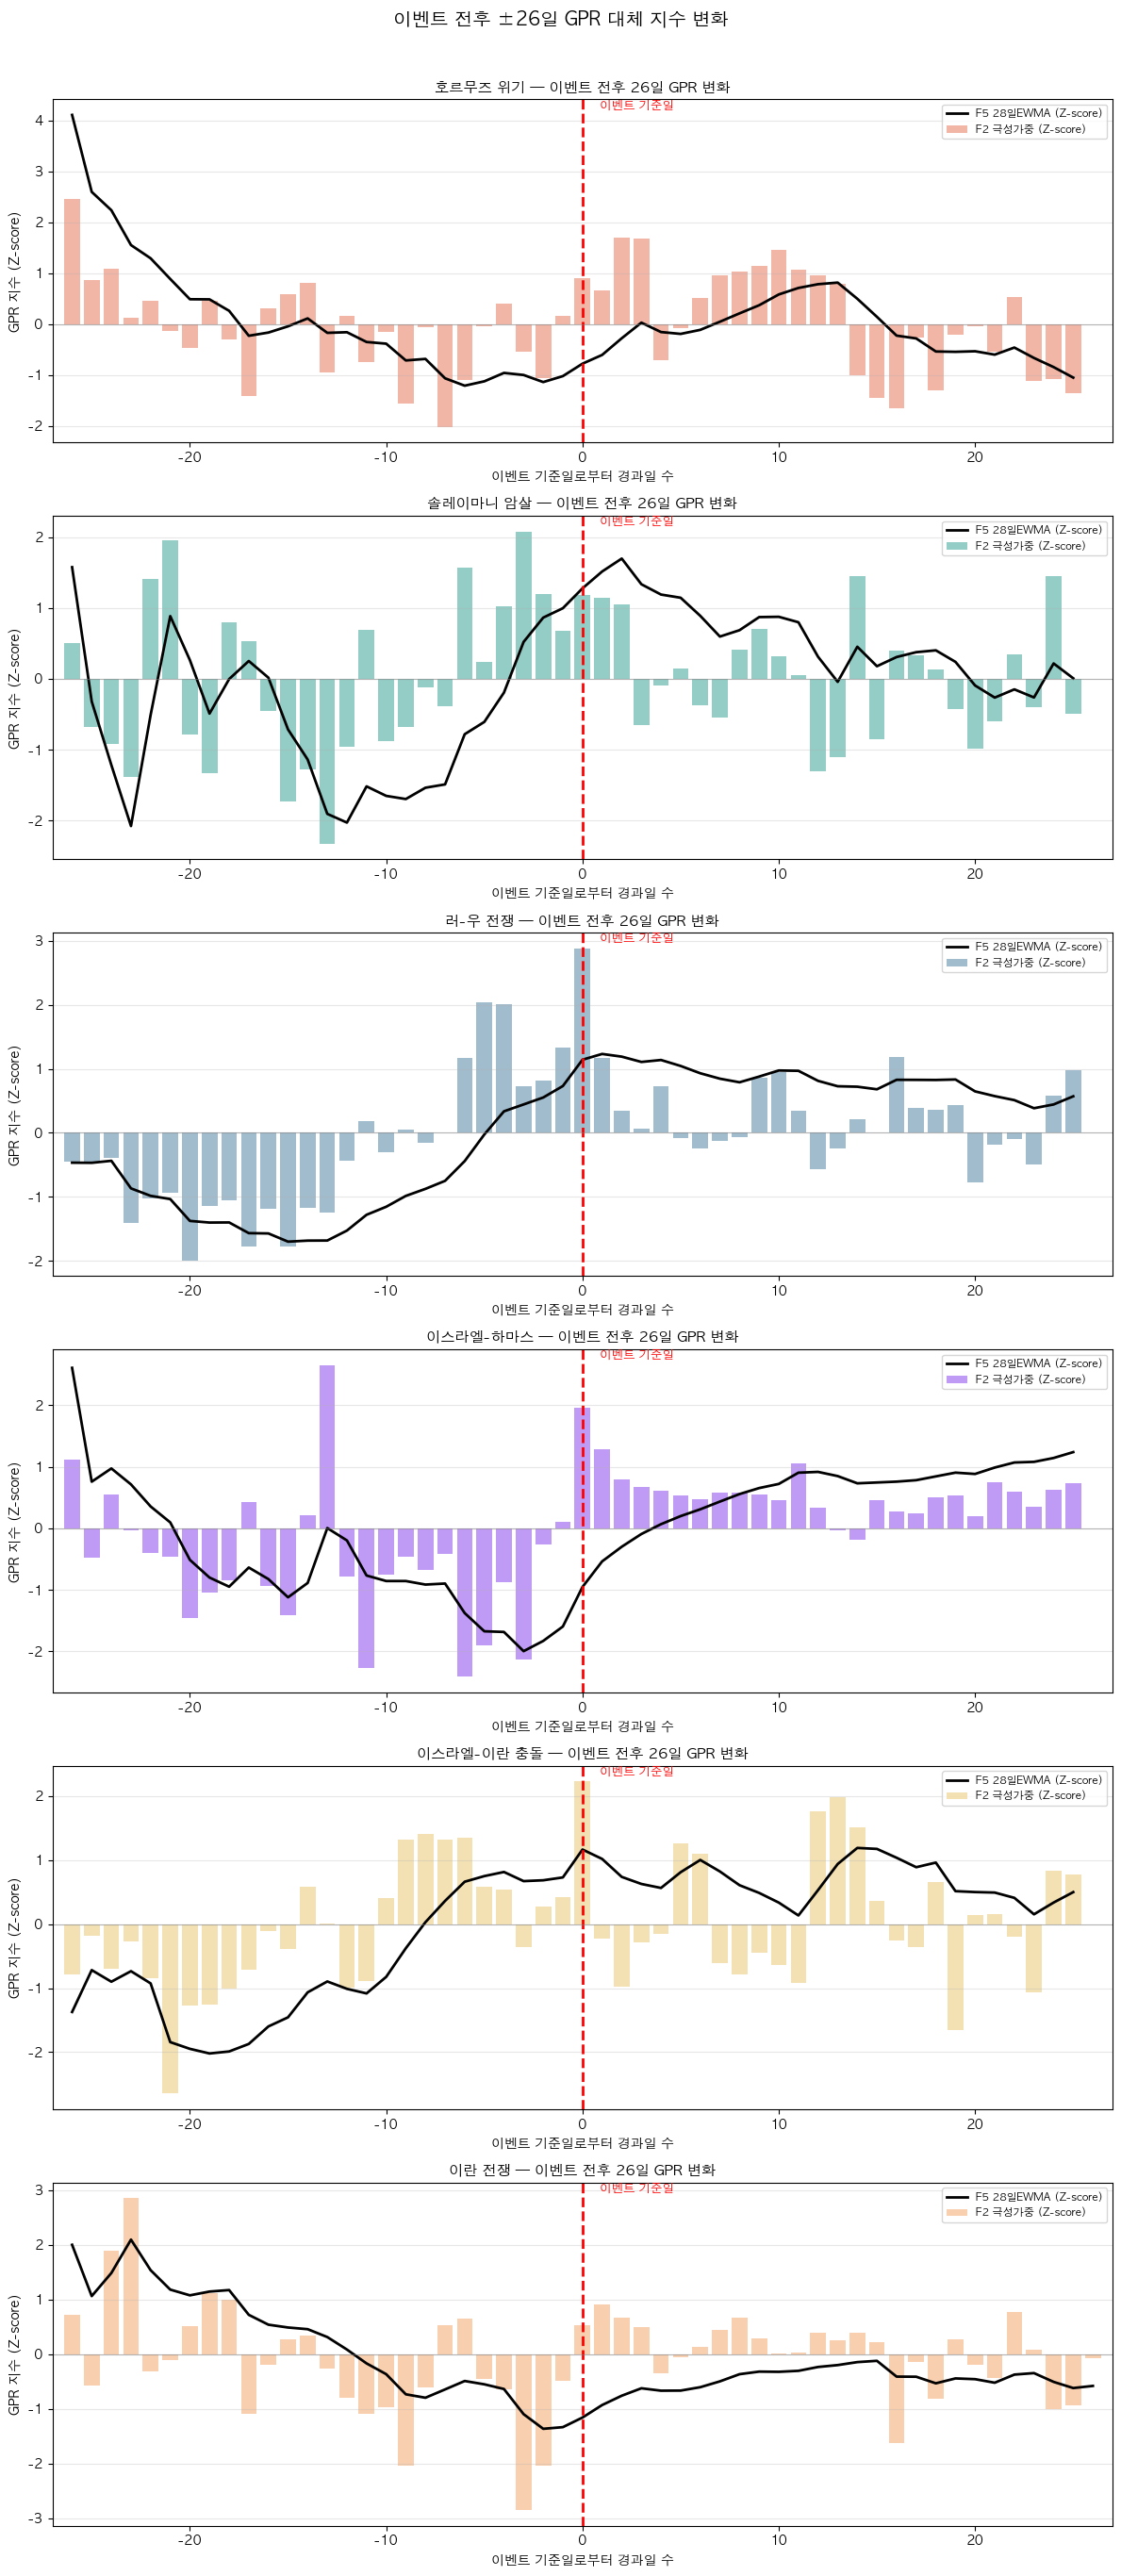

저장: 07_event_window.png


In [22]:
WINDOW = 26
n_events = len(merged_results)
fig, axes = plt.subplots(n_events, 1, figsize=(12, 4.5 * n_events))
if n_events == 1:
    axes = [axes]

for ax, (event, result) in zip(axes, merged_results.items()):
    result   = result.copy()
    result['date'] = pd.to_datetime(result['date'])
    result   = result.sort_values('date')
    event_dt = pd.Timestamp(EVENT_DATES[event])
    color    = COLORS.get(event, 'steelblue')

    result['day_offset'] = (result['date'] - event_dt).dt.days
    window_data = result[result['day_offset'].between(-WINDOW, WINDOW)].copy()

    ax.bar(window_data['day_offset'], window_data['F2_z'],
           color=color, alpha=0.5, label='F2 극성가중 (Z-score)')
    ax.plot(window_data['day_offset'], window_data['F5_z'],
            color='black', lw=2, label='F5 28일EWMA (Z-score)')

    ax.axvline(0, color='red', lw=2, ls='--')
    # BUG-7 동일 패턴 수정: get_xaxis_transform() 사용
    ax.text(0.5, 1.0, '  이벤트 기준일', color='red', fontsize=9,
            va='top', transform=ax.get_xaxis_transform())
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5)

    ax.set_xlabel('이벤트 기준일로부터 경과일 수')
    ax.set_ylabel('GPR 지수 (Z-score)')
    ax.set_title(
        f'{EVENT_LABELS.get(event, event)} — 이벤트 전후 {WINDOW}일 GPR 변화',
        fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-WINDOW - 1, WINDOW + 1)

plt.suptitle(f'이벤트 전후 ±{WINDOW}일 GPR 대체 지수 변화', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('07_event_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_event_window.png')

---
## Step 8. 결과 저장

In [23]:
save_cols = [
    'date','event_name','event_date','N','mean_tone',
    'F1_raw','F2_raw','F3_raw','F4_raw','F5_raw',
    'F1_z','F2_z','F3_z','F4_z','F5_z',
]
if gpr_available:
    save_cols += ['GPR','GPR_zscore']

print('▶ 이벤트별 CSV 저장')
for event, result in merged_results.items():
    out_cols = [c for c in save_cols if c in result.columns]
    fname    = f'gpr_custom_{event}.csv'
    result[out_cols].to_csv(fname, index=False, encoding='utf-8-sig')
    print(f'  ✅ {fname}  ({len(result)}행)')

gpr_all_save = pd.concat(
    [r[[c for c in save_cols if c in r.columns]]
     for r in merged_results.values()],
    ignore_index=True)
gpr_all_save.to_csv('gpr_combined.csv', index=False, encoding='utf-8-sig')
print(f'\n  ✅ gpr_combined.csv  ({len(gpr_all_save)}행)')

if not corr_summary.empty:
    corr_summary.to_csv('gpr_correlation_summary.csv',
                        index=False, encoding='utf-8-sig')
    print('  ✅ gpr_correlation_summary.csv')

print('\n저장 완료')

▶ 이벤트별 CSV 저장
  ✅ gpr_custom_hormuz_crisis.csv  (52행)
  ✅ gpr_custom_soleimani_assassination.csv  (52행)
  ✅ gpr_custom_russia_ukraine_invasion.csv  (52행)
  ✅ gpr_custom_israel_hamas.csv  (52행)
  ✅ gpr_custom_israel_iran.csv  (52행)
  ✅ gpr_custom_us_israel_iran.csv  (55행)

  ✅ gpr_combined.csv  (315행)
  ✅ gpr_correlation_summary.csv

저장 완료


In [24]:
output_files = (
    [f'gpr_custom_{e}.csv' for e in EVENT_DATES if e in merged_results]
    + ['gpr_combined.csv','gpr_correlation_summary.csv',
       '01_raw_article_count.png','02_preprocessed_overview.png',
       '03_correlation_heatmap.png','04_scatter_matrix.png',
       '05_gpr_timeseries.png','06_official_vs_ours.png',
       '07_event_window.png']
)
print('▶ 최종 산출물\n')
print(f'{"파일명":<45} {"상태":>6} {"크기":>10}')
print('-' * 65)
for f in output_files:
    exists = os.path.exists(f)
    size   = f'{os.path.getsize(f)/1024:.1f} KB' if exists else '-'
    status = '✅' if exists else '❌ 없음'
    print(f'{f:<45} {status:>6} {size:>10}')
print()
print('─' * 65)
print('승기에게 전달: gpr_combined.csv')
print('  → 컬럼: date | event_name | N | mean_tone')
print('         F1_raw~F5_raw | F1_z~F5_z', end='')
if gpr_available:
    print(' | GPR | GPR_zscore')
else:
    print()
print('  → 추천 외생변수: F2_z (극성가중) 또는 F5_z (28일EWMA)')
print('  → GARCH 외생변수, 이벤트 스터디, 분위수 회귀에 활용')

▶ 최종 산출물

파일명                                               상태         크기
-----------------------------------------------------------------
gpr_custom_hormuz_crisis.csv                       ✅    14.8 KB
gpr_custom_soleimani_assassination.csv             ✅    15.2 KB
gpr_custom_russia_ukraine_invasion.csv             ✅    15.3 KB
gpr_custom_israel_hamas.csv                        ✅    14.6 KB
gpr_custom_israel_iran.csv                         ✅    14.6 KB
gpr_custom_us_israel_iran.csv                      ✅    15.7 KB
gpr_combined.csv                                   ✅    89.6 KB
gpr_correlation_summary.csv                        ✅     3.9 KB
01_raw_article_count.png                           ✅   104.1 KB
02_preprocessed_overview.png                       ✅   265.2 KB
03_correlation_heatmap.png                         ✅   140.1 KB
04_scatter_matrix.png                              ✅   882.3 KB
05_gpr_timeseries.png                              ✅  1659.0 KB
06_official_vs_ours.png     